# 04 – Correlation Analysis
In questo notebook analizzo il legame tra le feature estratte dall'accelerometro e gli indici cardiaci derivati dall'ECG, con particolare attenzione a **mean R-R** e **HR medio**. L'idea metodologica è verificare se l'intensità e la struttura del movimento osservate dai sensori ACC riflettono in modo coerente la risposta cardiovascolare dei pazienti cardiochirurgici durante la riabilitazione.

Scelgo di riportare **sia Pearson sia Spearman** perché descrivono aspetti complementari: Pearson misura il legame lineare, mentre Spearman valuta la monotonicità ed è più robusto in presenza di outlier o distribuzioni non gaussiane, condizioni realistiche in segnali fisiologici reali. Nel workflow complessivo, quando il confronto è tra due gruppi come **REST vs ACTIVITY**, affiancare al test parametrico anche il **Mann-Whitney U** è utile perché le feature HRV e ACC possono avere asimmetrie e code che rendono prudente una verifica non parametrica.


In [1]:
import sys; sys.path.insert(0, '..')  # Rendo importabili i moduli del progetto a partire dalla cartella notebooks
import warnings; warnings.filterwarnings('ignore')  # Evito warning ripetitivi per mantenere leggibile l'analisi esplorativa
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src.correlation_analysis import (
    compute_correlations, correlation_matrix, linear_regression_summary,
    compare_rest_vs_activity, plot_correlation_heatmap, plot_scatter_regression)  # Richiamo tutte le utility statistiche già definite nel progetto
sns.set_theme(style='whitegrid')  # Uno stile uniforme aiuta a confrontare meglio pattern e dispersione tra figure diverse
%matplotlib inline
full_df = pd.read_csv('../results/tables/features_all.csv')  # Carico la tabella finale delle feature già sincronizzate tra ECG e ACC
print('Shape:', full_df.shape)  # Verifico la numerosità: è importante per interpretare p-value molto piccoli
print('Test labels:', full_df['test_label'].unique())  # Controllo che siano presenti sia REST sia i test motori attesi


Shape: (16086, 89)
Test labels: ['VELO' 'TUG' '6MWT' 'GAIT_ANALYSIS' 'STAIR' 'REST']


## 1. Top correlazioni ACC ↔ mean R-R
Qui considero **mean R-R** come proxy inverso della frequenza cardiaca: se l'intervallo R-R si accorcia, la FC aumenta. Per questo motivo un coefficiente **negativo** tra una feature di movimento e mean R-R ha una lettura fisiologica sensata: all'aumentare della cadenza o dell'intensità del gesto motorio, il cuore accelera e quindi il tempo medio tra due battiti diminuisce.

La lettura congiunta di Pearson e Spearman mi permette di capire se l'associazione è solo lineare oppure più genericamente monotona. In un dataset di riabilitazione, dove i pazienti eseguono attività diverse e con intensità non perfettamente sovrapponibili, questa doppia vista è più convincente di un singolo coefficiente.


In [2]:
acc_cols = [c for c in full_df.columns if c.startswith('acc_')]  # Isolo solo le feature accelerometriche per confrontarle con la risposta cardiaca
corr_rr = compute_correlations(full_df, ecg_col='ecg_mean_rr', acc_cols=acc_cols)  # La funzione restituisce insieme Pearson e Spearman, così confronto linearità e monotonicità
print('Top 15 correlazioni con mean_RR:')
print(corr_rr.head(15).to_string(index=False))  # Mostro le feature più associate in valore assoluto per evidenziare subito i candidati più informativi


Top 15 correlazioni con mean_RR:
                feature  pearson_r     pearson_p  spearman_r    spearman_p     n
       acc_mag_dom_freq  -0.297865  0.000000e+00   -0.319888  0.000000e+00 16086
      acc_mag_jerk_mean  -0.216565 4.932408e-170   -0.241046 2.240466e-211 16086
        acc_z_jerk_mean  -0.202834 5.755553e-149   -0.211467 4.901635e-162 16086
        acc_x_jerk_mean  -0.201363 8.479925e-147   -0.190599 1.890020e-131 16086
  acc_z_spectral_energy  -0.179311 2.536527e-116   -0.196374 1.429736e-139 16086
acc_mag_spectral_energy  -0.162160  3.298530e-95   -0.170307 5.854114e-105 16086
      acc_max_intercorr   0.155481  1.372428e-87    0.167640 1.034810e-101 16086
         acc_mag_energy  -0.155103  3.620007e-87   -0.183510 7.790535e-122 16086
          acc_x_entropy  -0.154997  4.743162e-87   -0.159837  1.605621e-92 16086
           acc_mag_mean  -0.151326  5.117981e-83   -0.194829 2.256982e-137 16086
              acc_z_std  -0.148227  1.081165e-79   -0.181980 8.242914e-120 1

## 2. Top correlazioni ACC ↔ HR medio
Ripeto l'analisi usando **HR medio** invece di mean R-R per ottenere una lettura più immediata in termini clinici, perché i bpm sono più intuitivi da discutere rispetto ai millisecondi. Mi aspetto quindi che le feature ACC più dinamiche mostrino un'associazione **positiva** con HR medio, coerente con l'aumento del fabbisogno cardiovascolare durante il movimento.

Il confronto tra questa tabella e quella precedente è utile anche come controllo di coerenza interna: dato che HR e R-R sono inversamente collegati, le feature più rilevanti dovrebbero comparire in entrambe le analisi con segno opposto.


In [3]:
corr_hr = compute_correlations(full_df, ecg_col='ecg_hr_mean', acc_cols=acc_cols)  # Uso lo stesso set di feature per confrontare una metrica cardiaca direttamente espressa in bpm
print('Top 10 correlazioni con HR_mean:')
print(corr_hr.head(10).to_string(index=False))  # Se i risultati sono fisiologicamente coerenti, le feature motorie più intense dovrebbero salire in classifica anche qui


Top 10 correlazioni con HR_mean:
              feature  pearson_r     pearson_p  spearman_r    spearman_p     n
     acc_mag_dom_freq   0.407143  0.000000e+00    0.318861  0.000000e+00 16086
        acc_x_entropy   0.167347 2.333605e-101    0.158809  2.413424e-91 16086
      acc_mag_entropy   0.166933 7.354355e-101    0.115164  1.271974e-48 16086
       acc_x_dom_freq   0.157739  3.970942e-90    0.093070  2.768500e-32 16086
    acc_max_intercorr  -0.146092  1.920369e-77   -0.166920 7.619278e-101 16086
          acc_corr_yz  -0.137320  1.484029e-68   -0.151205  6.909654e-83 16086
      acc_x_jerk_mean   0.136168  1.979775e-67    0.188067 5.693741e-128 16086
acc_z_spectral_energy   0.127956  1.079404e-59    0.198771 5.093714e-143 16086
    acc_mag_jerk_mean   0.126859  1.071351e-58    0.235566 1.075634e-201 16086
      acc_z_jerk_mean   0.126192  4.271316e-58    0.204863 5.523412e-152 16086


## 3. Heatmap matrice di correlazione
La heatmap serve come vista globale del sistema di feature: non guarda solo il rapporto ACC-ECG, ma anche le ridondanze tra feature simili. Questo passaggio è utile perché in segnali biomeccanici molte variabili derivate dalla stessa finestra possono essere fortemente correlate tra loro.

Dal punto di vista metodologico, osservare blocchi molto omogenei aiuta a capire se alcune feature stanno raccontando la stessa informazione con nomi diversi. Questo è importante sia per l'interpretazione fisiologica sia per evitare modelli inutilmente ridondanti.


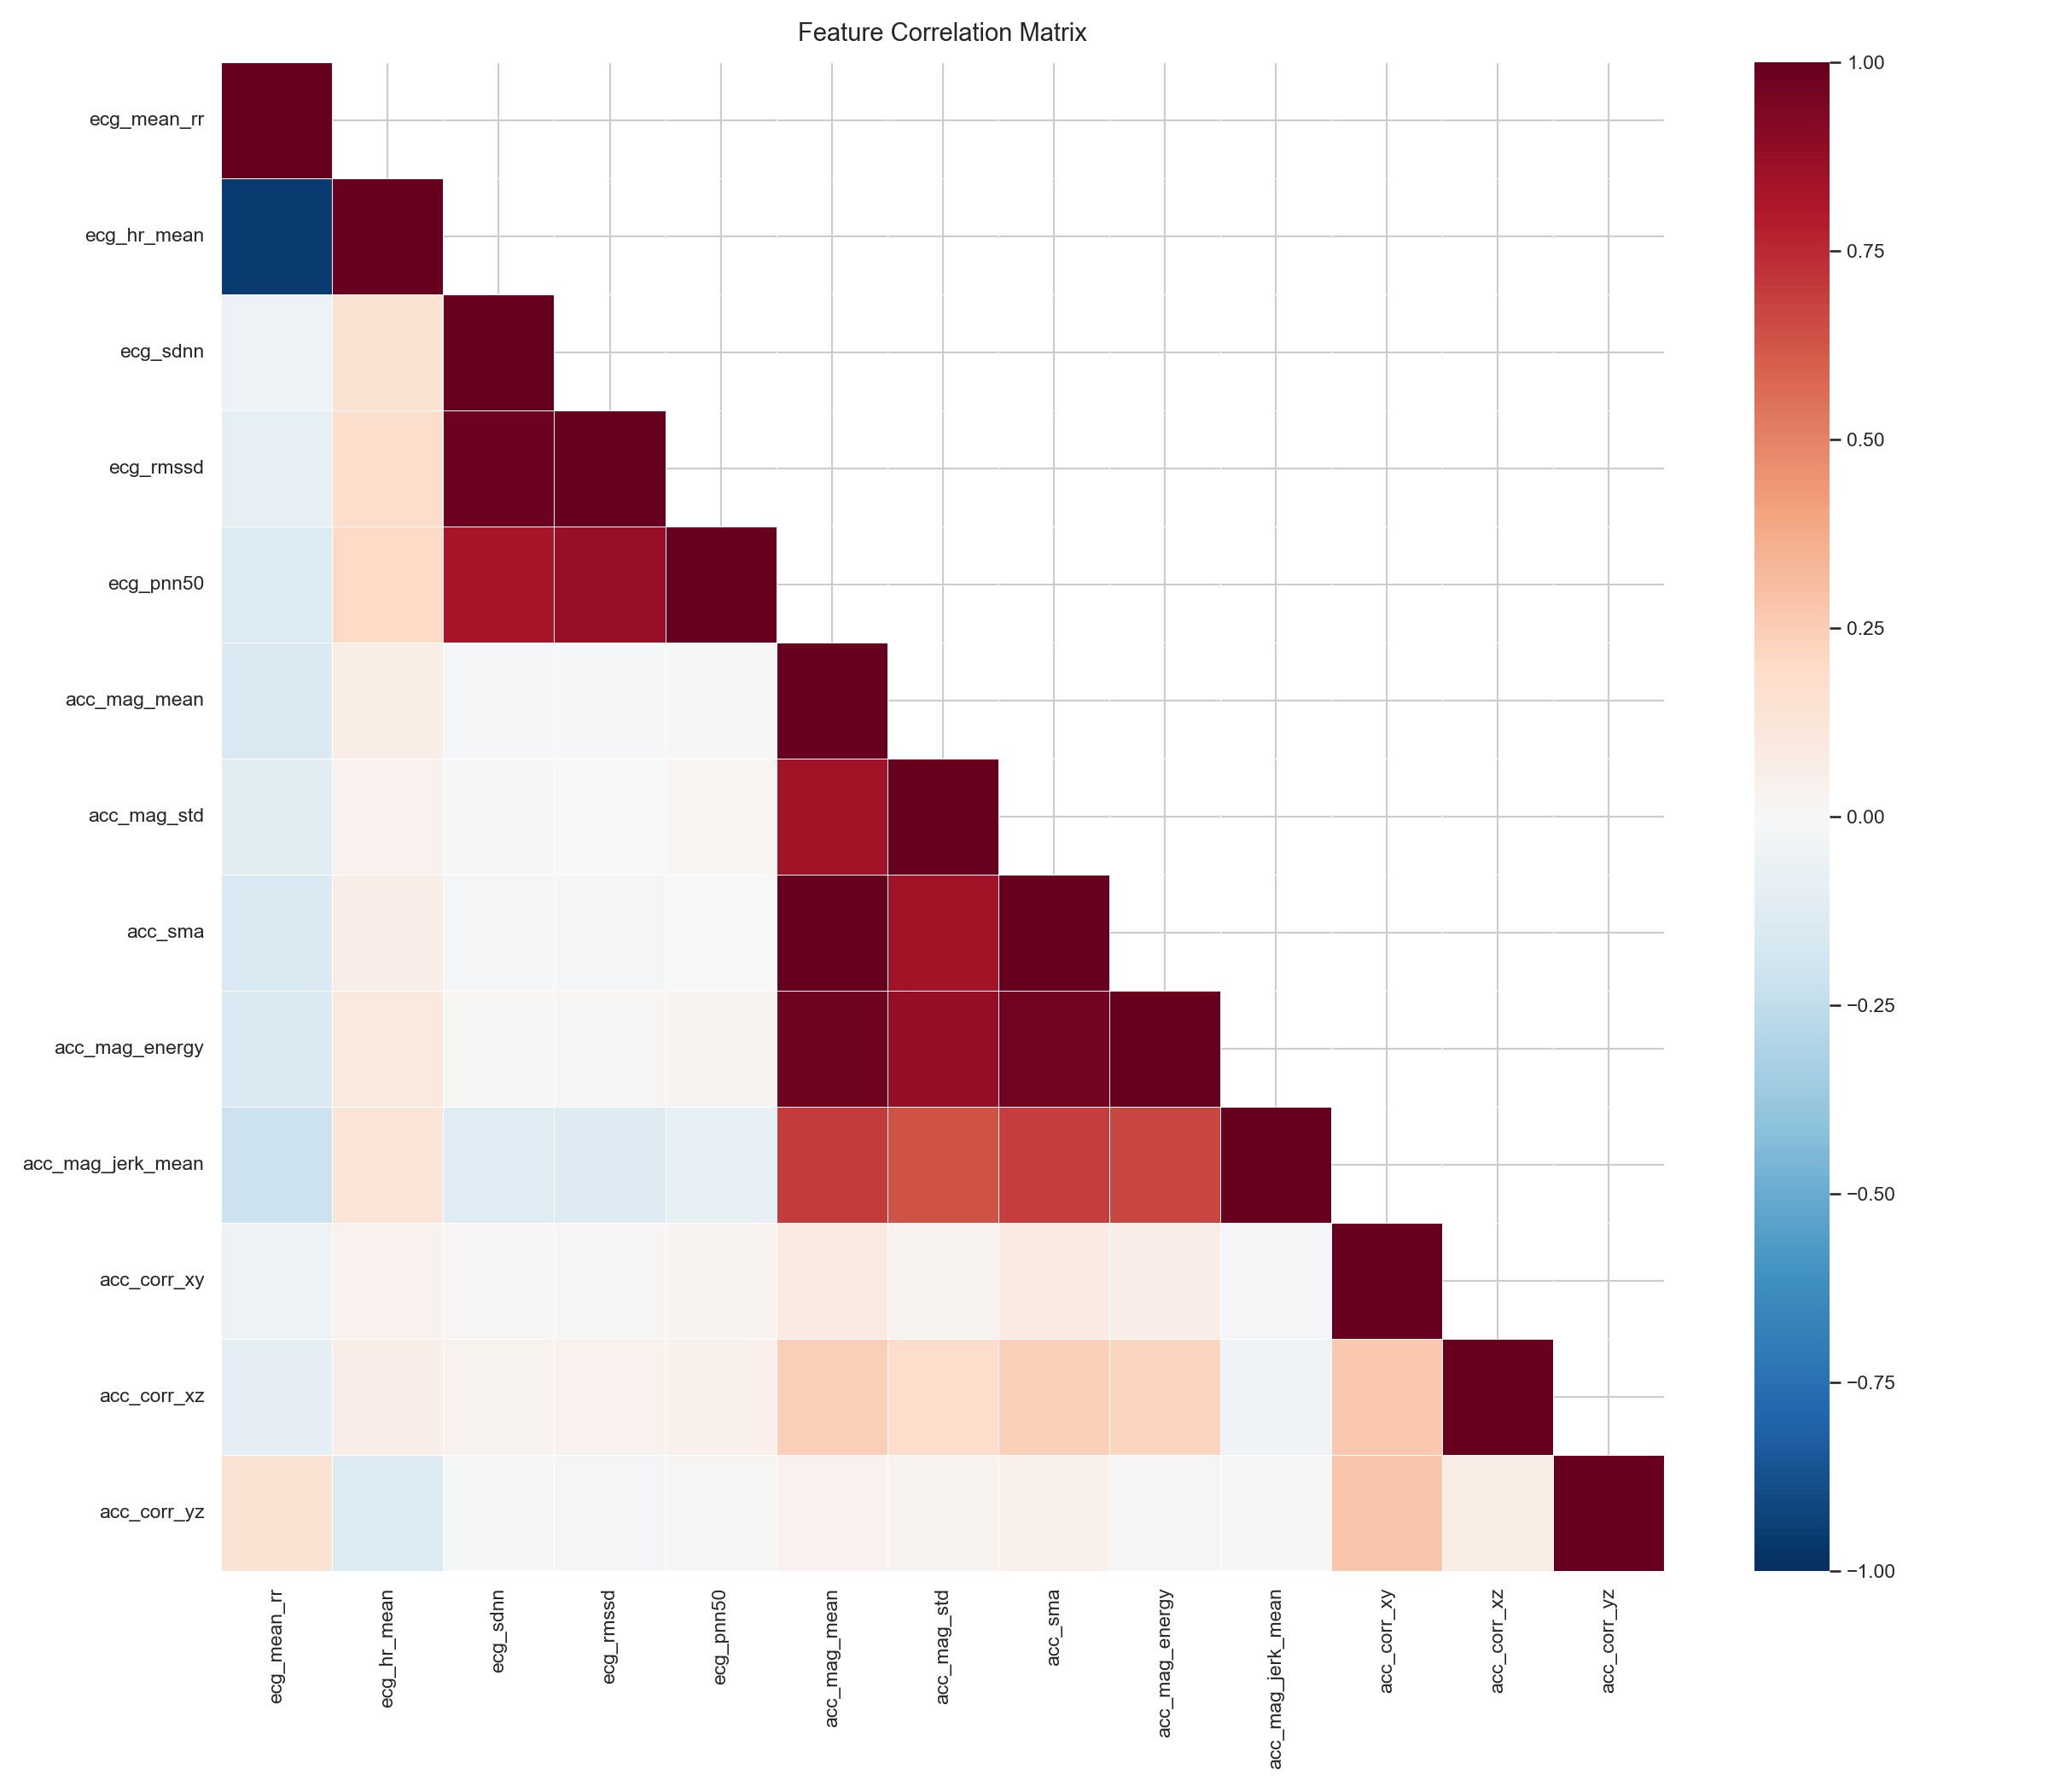

In [4]:
key_cols = ['ecg_mean_rr','ecg_hr_mean','ecg_sdnn','ecg_rmssd','ecg_pnn50',  # Tengo insieme indici di livello, variabilità e componente vagale dell'ECG
            'acc_mag_mean','acc_mag_std','acc_sma','acc_mag_energy',  # Sul lato ACC scelgo feature di ampiezza e intensità del movimento
            'acc_mag_jerk_mean','acc_corr_xy','acc_corr_xz','acc_corr_yz']  # Aggiungo jerk e correlazioni assiali per cogliere fluidità e coordinazione del gesto
cmat = correlation_matrix(full_df, cols=key_cols)  # La matrice aiuta a leggere in un colpo solo sinergie e ridondanze tra feature selezionate
plot_correlation_heatmap(cmat, output_path='../results/figures/corr_heatmap.png')  # Salvo la figura per poterla riutilizzare direttamente nella tesi
from IPython.display import Image; Image('../results/figures/corr_heatmap.png')  # Visualizzo il file esportato per controllare il risultato finale realmente salvato


## 4. Regressione lineare — feature più correlate
Dopo la fase descrittiva, una regressione lineare semplice aiuta a quantificare meglio la relazione tra ogni feature ACC e mean R-R. Non mi interessa qui costruire un modello predittivo completo, ma stimare **direzione del coefficiente**, **forza del fit** e significatività statistica per ciascuna feature in modo facilmente commentabile nel testo di tesi.

In particolare, il coefficiente angolare permette una lettura intuitiva: se la pendenza è negativa, un aumento della feature di movimento tende ad accompagnarsi a una riduzione dell'intervallo R-R, quindi a una maggiore frequenza cardiaca.


In [5]:
reg = linear_regression_summary(full_df, target_col='ecg_mean_rr', feature_cols=acc_cols)  # Valuto separatamente ogni feature ACC rispetto a mean R-R per ottenere una misura interpretabile del trend
print(reg.head(10).to_string(index=False))  # Ordino per qualità del fit per concentrarmi sulle associazioni più solide
reg.to_csv('../results/tables/linear_regression_rr.csv', index=False)  # Esporto la tabella così da poter citare i risultati numerici senza ricalcolarli


                feature      slope   intercept  r_squared       p_value  std_err     n
       acc_mag_dom_freq -60.096785  901.504824   0.088724  0.000000e+00 1.518657 16086
      acc_mag_jerk_mean  -0.500697  931.746342   0.046900 4.932408e-170 0.017798 16086
        acc_z_jerk_mean  -0.385394  916.648742   0.041142 5.755553e-149 0.014670 16086
        acc_x_jerk_mean  -0.377050  903.999321   0.040547 8.479925e-147 0.014462 16086
  acc_z_spectral_energy  -0.573740  873.751542   0.032152 2.536527e-116 0.024821 16086
acc_mag_spectral_energy  -1.036350  876.702683   0.026296  3.298530e-95 0.049726 16086
      acc_max_intercorr 128.305642  795.898279   0.024174  1.372428e-87 6.427729 16086
         acc_mag_energy  -0.250528  872.926304   0.024057  3.620007e-87 0.012582 16086
          acc_x_entropy -78.442414 1060.378673   0.024024  4.743162e-87 3.942292 16086
           acc_mag_mean  -6.525875  898.690912   0.022899  5.117981e-83 0.336123 16086


## 5. Scatter plot — top feature
Lo scatter plot è un controllo visivo indispensabile perché evita di affidarsi solo ai coefficienti sintetici. Una correlazione statisticamente significativa, soprattutto con molte finestre, può nascere anche da pattern non lineari o da cluster distinti per attività; vedere i punti aiuta quindi a capire se il risultato è davvero coerente.

Se la feature migliore è `acc_mag_dom_freq`, un andamento decrescente rispetto a mean R-R è plausibile: una **frequenza dominante del movimento** più alta suggerisce passi o gesti più rapidi, che fisiologicamente si associano a FC maggiore e quindi a R-R più breve.


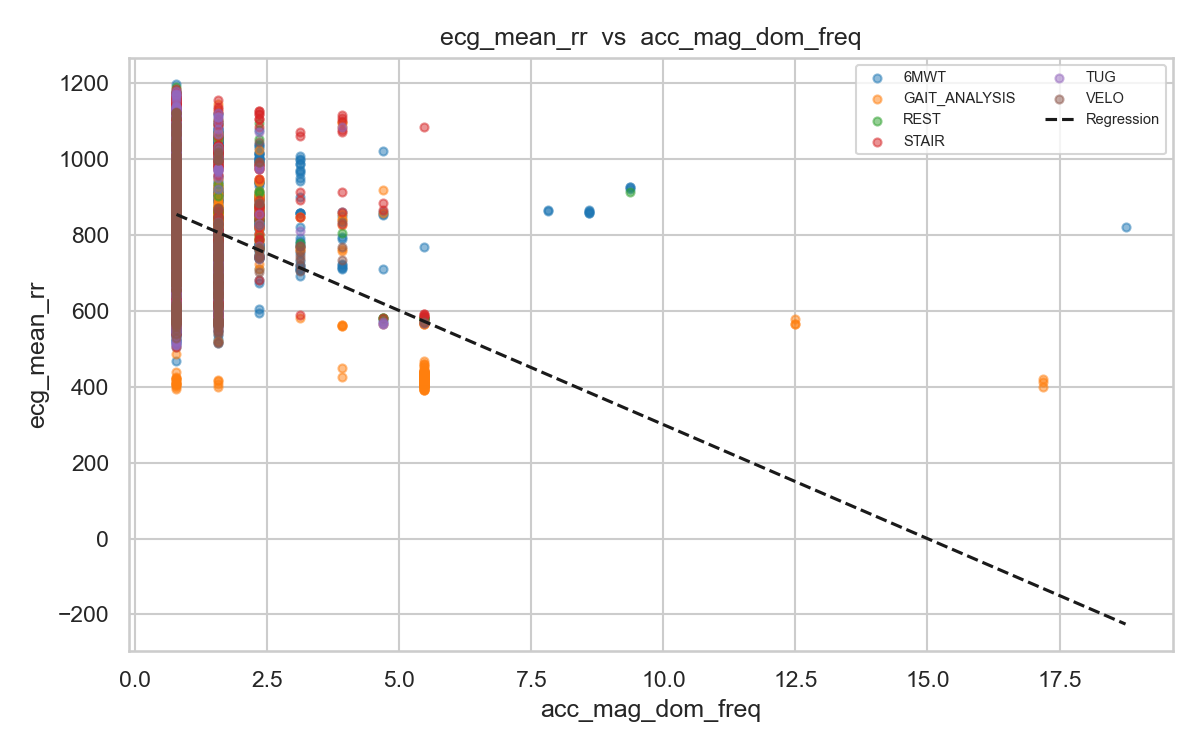

In [6]:
top_feat = corr_rr.iloc[0]['feature']  # Seleziono automaticamente la feature con associazione più forte per non introdurre scelte arbitrarie
plot_scatter_regression(full_df, x_col=top_feat,
    output_path=f'../results/figures/scatter_{top_feat}.png')  # Aggiungo la retta di regressione per confrontare percezione visiva e coefficiente calcolato
from IPython.display import Image; Image(f'../results/figures/scatter_{top_feat}.png')  # Mostro l'immagine finale già salvata, utile anche per la successiva esportazione nella tesi


## 6. Correlazione per tipo di test
L'ultima verifica scompone l'analisi per test motorio, perché il rapporto tra movimento e risposta cardiaca non è necessariamente identico in STAIR, 6MWT, TUG, VELO o GAIT. Questa scelta è metodologicamente importante: un'unica correlazione globale potrebbe mascherare dinamiche diverse tra attività più continue e attività più brevi o intermittenti.

Quando invece il confronto viene ridotto a due sole condizioni, ad esempio **REST vs ACTIVITY**, considero appropriato affiancare il **Mann-Whitney U** ai test parametrici perché le distribuzioni di feature fisiologiche in riabilitazione possono essere sbilanciate e non gaussiane.


In [7]:
from src.config import TEST_LABELS
for lbl in TEST_LABELS:
    sub = full_df[full_df['test_label'] == lbl]  # Analizzo ogni test separatamente per capire se la feature dominante cambia con il contesto motorio
    if len(sub) < 10: continue  # Evito stime poco stabili quando il numero di finestre per un test è troppo basso
    c = compute_correlations(sub, acc_cols=acc_cols).iloc[0]  # Estraggo la feature ACC più associata all'ECG all'interno di quel singolo task
    print(f'{lbl:15s}  top: {c["feature"]:30s}  r={c["pearson_r"]:+.3f}  p={c["pearson_p"]:.3e}')  # Riassumo il pattern principale in formato compatto e confrontabile


STAIR            top: acc_x_jerk_mean                 r=-0.242  p=1.464e-32
6MWT             top: acc_mag_jerk_mean               r=-0.296  p=1.522e-114
TUG              top: acc_x_entropy                   r=-0.410  p=4.655e-72
VELO             top: acc_mag_jerk_mean               r=-0.347  p=2.148e-36
GAIT_ANALYSIS    top: acc_mag_dom_freq                r=-0.496  p=9.994e-263
